# 司机周报 (Weekly Report)
## 当前周数据概览与周对周对比

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Setup Chinese font
font_path = 'wqy_microhei.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
fm.fontManager.addfont(font_path)

# Read current week data
df_current = pd.read_excel('dwa/dwa_260216.xlsx')
print(f"当前周司机数量: {len(df_current)}")

current_week = '02/16'

# Read previous week data for comparison
df_previous = pd.read_excel('dwa/dwa_260209.xlsx')
print(f"上周司机数量: {len(df_previous)}")

# Find common drivers
common_drivers = set(df_current['司机'].values) & set(df_previous['司机'].values)
print(f"共同司机: {len(common_drivers)}")

# Filter for common drivers
df_prev_common = df_previous[df_previous['司机'].isin(common_drivers)].sort_values('司机').reset_index(drop=True)
df_curr_common = df_current[df_current['司机'].isin(common_drivers)].sort_values('司机').reset_index(drop=True)

当前周司机数量: 9
上周司机数量: 9
共同司机: 9


## 四图概览

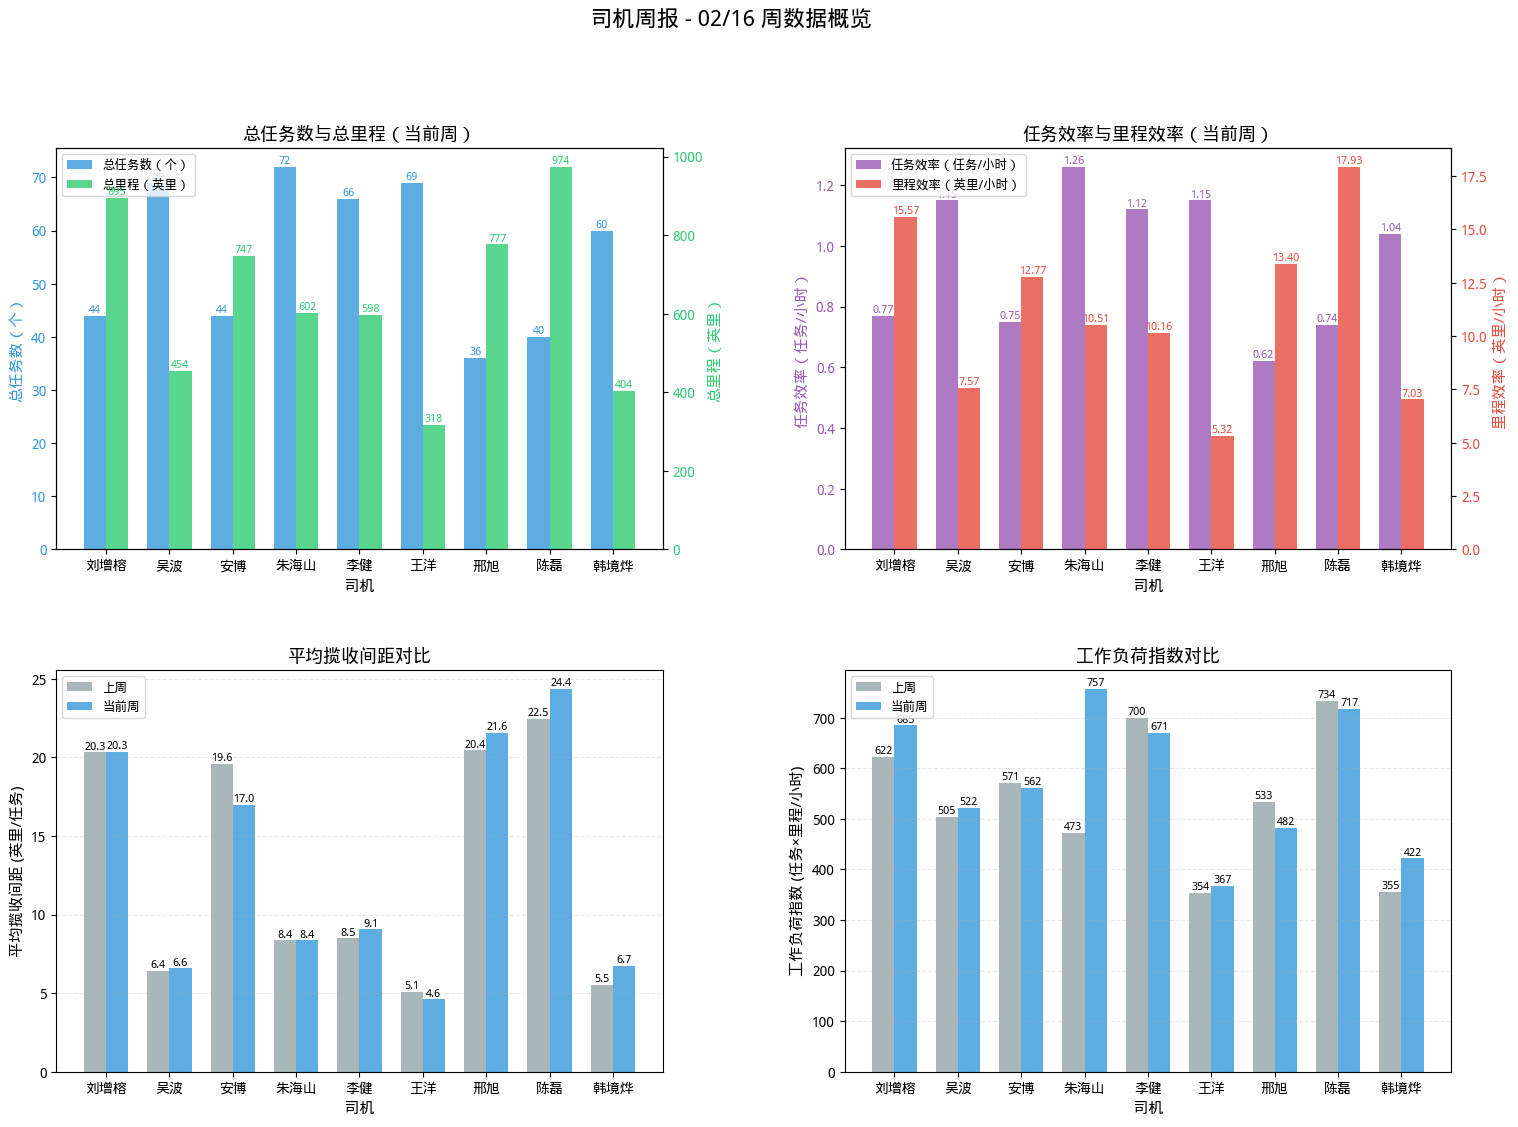

In [2]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

drivers = df_curr_common['司机'].values
x_pos = range(len(drivers))
bar_width = 0.35

# ========================================
# 左上: 总任务数与总里程（双轴）- 当前周数据
# ========================================
ax1 = fig.add_subplot(gs[0, 0])
ax1_right = ax1.twinx()

bars_tasks = ax1.bar([i - bar_width/2 for i in x_pos], 
                      df_curr_common['总任务(个)'], 
                      bar_width, 
                      label='总任务数（个）', 
                      color='#3498db', 
                      alpha=0.8)

bars_mileage = ax1_right.bar([i + bar_width/2 for i in x_pos], 
                              df_curr_common['总里程(英里)'], 
                              bar_width, 
                              label='总里程（英里）', 
                              color='#2ecc71', 
                              alpha=0.8)

ax1.set_xlabel('司机', fontsize=11)
ax1.set_ylabel('总任务数（个）', fontsize=11, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(drivers, fontsize=10)

ax1_right.set_ylabel('总里程（英里）', fontsize=11, color='#2ecc71')
ax1_right.tick_params(axis='y', labelcolor='#2ecc71')

# Add value labels
for bar in bars_tasks:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8, color='#3498db', weight='bold')

for bar in bars_mileage:
    height = bar.get_height()
    ax1_right.text(bar.get_x() + bar.get_width()/2, height,
                   f'{int(height)}', ha='center', va='bottom', fontsize=8, color='#2ecc71', weight='bold')

ax1.set_title('总任务数与总里程（当前周）', fontsize=13, weight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ========================================
# 右上: 任务效率与里程效率（双轴）- 当前周数据
# ========================================
ax2 = fig.add_subplot(gs[0, 1])
ax2_right = ax2.twinx()

bars_task_eff = ax2.bar([i - bar_width/2 for i in x_pos], 
                         df_curr_common['任务效率(任务/小时)'], 
                         bar_width, 
                         label='任务效率（任务/小时）', 
                         color='#9b59b6', 
                         alpha=0.8)

bars_mile_eff = ax2_right.bar([i + bar_width/2 for i in x_pos], 
                               df_curr_common['里程效率(英里/小时)'], 
                               bar_width, 
                               label='里程效率（英里/小时）', 
                               color='#e74c3c', 
                               alpha=0.8)

ax2.set_xlabel('司机', fontsize=11)
ax2.set_ylabel('任务效率（任务/小时）', fontsize=11, color='#9b59b6')
ax2.tick_params(axis='y', labelcolor='#9b59b6')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(drivers, fontsize=10)

ax2_right.set_ylabel('里程效率（英里/小时）', fontsize=11, color='#e74c3c')
ax2_right.tick_params(axis='y', labelcolor='#e74c3c')

# Add value labels
for bar in bars_task_eff:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=8, color='#9b59b6', weight='bold')

for bar in bars_mile_eff:
    height = bar.get_height()
    ax2_right.text(bar.get_x() + bar.get_width()/2, height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=8, color='#e74c3c', weight='bold')

ax2.set_title('任务效率与里程效率（当前周）', fontsize=13, weight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ========================================
# 左下: 平均揽收间距对比（上周 vs 当前周）
# ========================================
ax3 = fig.add_subplot(gs[1, 0])

pickup_dist_prev = df_prev_common['平均揽收间距(英里/任务)'].values
pickup_dist_curr = df_curr_common['平均揽收间距(英里/任务)'].values

bars_prev = ax3.bar([i - bar_width/2 for i in x_pos], 
                     pickup_dist_prev, 
                     bar_width,
                     label='上周', 
                     color='#95a5a6', 
                     alpha=0.8)

bars_curr = ax3.bar([i + bar_width/2 for i in x_pos], 
                     pickup_dist_curr, 
                     bar_width,
                     label='当前周', 
                     color='#3498db', 
                     alpha=0.8)

ax3.set_ylabel('平均揽收间距 (英里/任务)', fontsize=11, weight='bold')
ax3.set_xlabel('司机', fontsize=11)
ax3.set_title('平均揽收间距对比', fontsize=13, weight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(drivers, fontsize=10)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars_prev:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=8)

for bar in bars_curr:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# ========================================
# 右下: 工作负荷指数对比（上周 vs 当前周）
# ========================================
ax4 = fig.add_subplot(gs[1, 1])

workload_prev = df_prev_common['工作负荷指数(任务×里程/小时)'].values
workload_curr = df_curr_common['工作负荷指数(任务×里程/小时)'].values

bars_prev = ax4.bar([i - bar_width/2 for i in x_pos], 
                     workload_prev, 
                     bar_width,
                     label='上周', 
                     color='#95a5a6', 
                     alpha=0.8)

bars_curr = ax4.bar([i + bar_width/2 for i in x_pos], 
                     workload_curr, 
                     bar_width,
                     label='当前周', 
                     color='#3498db', 
                     alpha=0.8)

ax4.set_ylabel('工作负荷指数 (任务×里程/小时)', fontsize=11, weight='bold')
ax4.set_xlabel('司机', fontsize=11)
ax4.set_title('工作负荷指数对比', fontsize=13, weight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(drivers, fontsize=10)
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars_prev:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=8)

for bar in bars_curr:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'司机周报 - {current_week} 周数据概览', fontsize=16, weight='bold', y=0.995)
plt.show()